This notebook takes the results from the simulated ecophysiological modeling and compares to the observational reconstructed gradient to produce the main text figure 4 and the calculate the comparative statistics.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error
import scipy.io

# Figure 4 panel A

In [30]:
obs = pd.read_csv(r"C:\Users\prowa\Projects\R\Latitudinal_Extinction_Gradients\data_files\lat_ext_grad_10degbin_iqr.csv", )

obs = obs.drop(0)
obs= obs.rename(columns = {obs.columns[0]:"latbin",
                           obs.columns[1]:"median",
                           obs.columns[2]:"q1",
                           obs.columns[3]:"q3",
                           obs.columns[4]:"iqr"})
obs = obs.apply(pd.to_numeric, errors='coerce') # this is essential it thinks first two columns are strings
obs.head()

,latbin,median,q1,q3,iqr
1,-45.0,40,32.00,45.0,13.0
2,-35.0,33,26.00,41.0,15.0
3,-25.0,50,41.75,53.0,11.0
4,-15.0,26,21.00,35.0,14.0
5,-5.0,41,32.00,50.0,18.0


In [31]:
mat = scipy.io.loadmat(r"../data_files/model_output/LD_extinction.mat")
models = pd.read_csv(r"../data_files/model_output/idealized_scenarios.csv")

In [32]:
# read in the .mat file of ecophyiologicalmodel sims
mat['X_lat']
mat['lat'].T

sims = np.concatenate([mat['lat'].T,mat['X_lat']], axis = 0)

sims
#convert to Df
sims_df = pd.DataFrame(sims.T)

sims_df = sims_df.rename(columns={sims_df.columns[0]:'lat'})
sims_df.head()

,lat,1,2,3,4,5,6,7,8,9,...,463,464,465,466,467,468,469,470,471,472
0,-76.463797,10.729449,5.061856,10.729449,5.061856,12.799664,1.087608,5.061856,1.087608,12.799664,...,5.252420,NaN,6.513335,6.470769,3.038477,6.470769,3.038477,6.530797,3.038477,6.530797
1,-66.443536,8.130853,10.593968,11.128119,11.022086,13.186201,12.962663,12.410943,12.853825,7.868011,...,15.793698,NaN,16.717569,13.119946,13.710884,13.461891,14.328497,18.452737,14.890964,18.452737
2,-59.441568,9.640331,9.796005,11.998949,10.624131,13.816769,11.900524,12.210831,11.648251,9.425230,...,15.980357,NaN,16.646527,14.161787,14.139344,14.372888,14.486836,18.737909,15.517059,18.737909
3,-53.663942,18.908938,8.511837,20.643208,8.511837,22.534047,0.000000,8.511837,0.000000,20.494375,...,1.766730,NaN,2.460323,12.945395,4.973013,13.709960,4.973013,3.512951,4.973013,3.512951
4,-48.590378,12.317519,4.216796,13.850475,4.216796,15.521825,0.000000,4.216796,0.000000,13.718919,...,3.977317,NaN,4.644093,7.985412,3.729240,8.588079,3.729240,7.486617,4.295529,7.486617


In [33]:
%%capture
############### Run only once or del obs
merged_df = obs.copy()

# add to sims_df latbin interploateion to obs data  

for col in sims_df.columns[1:]:
    merged_df[f'{col}'] = np.interp(merged_df['latbin'], sims_df['lat'], sims_df[col])

# add ideal simulations

ideal = models[models.columns[0:3]]

for col in ideal.columns[1:]:
    merged_df[f'{col}'] = np.interp(merged_df['latbin'], ideal['Latitude'], ideal[col])
merged_df.head()

In [34]:
#check for missing
merged_droped = merged_df.dropna(axis = 1)

diff = set(merged_df.columns) - set(merged_droped.columns)
diff

{'160',
 '18',
 '229',
 '254',
 '273',
 '314',
 '346',
 '368',
 '387',
 '402',
 '41',
 '417',
 '434',
 '449',
 '464',
 '71',
 '93'}

In [35]:
merged_df.columns

Index(['latbin', 'median', 'q1', 'q3', 'iqr', '1', '2', '3', '4', '5',
       ...
       '465', '466', '467', '468', '469', '470', '471', '472', 'deoxygenation',
       'cooling'],
      dtype='object', length=479)

In [36]:
# interval overlap

sim_cols = [col for col in merged_droped.columns if col not in ['latbin', 'median', 'q1', 'q3', 'iqr']]
in_iqr = (merged_droped[sim_cols] >= merged_droped['q1'].values[:, None]) & \
         (merged_droped[sim_cols] <= merged_droped['q3'].values[:, None]) #element wise tests true/false

dist_df = pd.DataFrame(in_iqr.sum(axis=0), columns=['n_in_iqr']) # np.sum()counts number of true along axis =0(row elements)

In [37]:
#calculate rmse
rmse = np.sqrt(
    ((merged_droped[sim_cols].subtract(merged_droped['median'], axis=0)) ** 2).mean()
)
rmse_df = pd.DataFrame(rmse, columns = ["rmse"])
results = rmse_df.join(dist_df)
results

,rmse,n_in_iqr
1,31.373048,0
2,25.395114,0
3,28.014887,0
4,24.430234,0
5,25.590713,0
...,...,...
470,12.810265,3
471,15.753281,2
472,12.810265,3
deoxygenation,13.503086,3


In [38]:
#rank by rmse
results_sorted = results.sort_values(by='rmse', ascending=True)
# print(results_sorted) 

best = results_sorted.iloc[0:49]
# best.head()

best = best[best.index.str.isnumeric()] # remove deoxygenation
best_cols = best.index.tolist()
best_cols = [int(col) for col in best.index.tolist()]
# best_cols # checked that these match sim_df with out offset

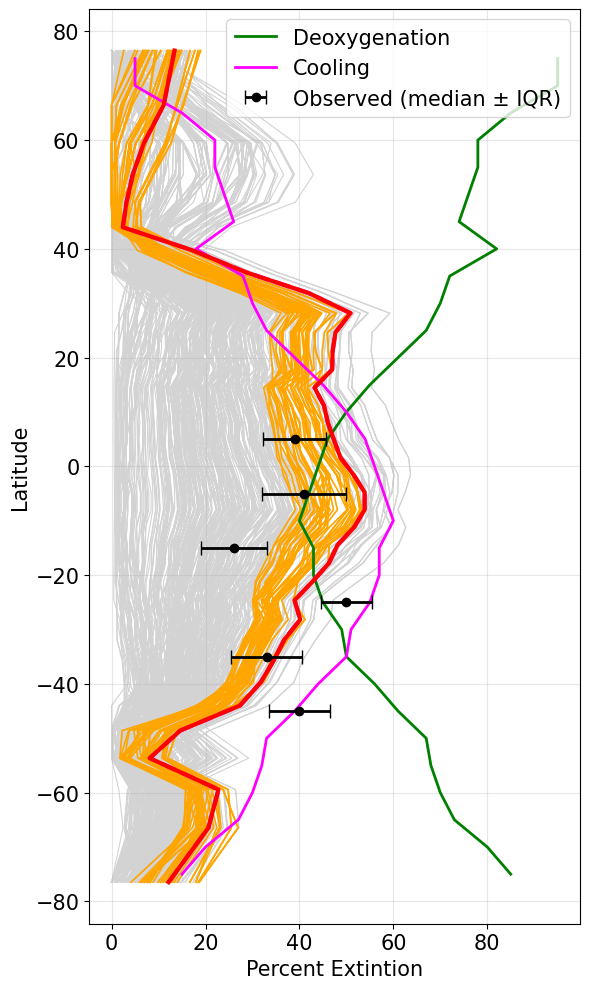

In [39]:
fig, ax = plt.subplots(figsize=(6, 10))

# for col in sims_df.columns[1:]:
#     if col in best_cols:
#         plt.plot(sims_df['lat'], sims_df[col],
#                  color='orange', linewidth=1.2, zorder=2)
        
#     else:
#         plt.plot(sims_df['lat'], sims_df[col],
#                  color='lightgrey', linewidth=0.8, zorder=1)

# you are matchs sims_df column index (this needs to be an integer
fig3 = [459]  
si = [457]  

for col in sims_df.columns[1:]:
    if col in fig3:
        plt.plot(sims_df[col], sims_df['lat'],
                 color='red', linewidth=3, zorder=3)
    if col in si:
        plt.plot(sims_df[col], sims_df['lat'],
                 color='magenta', linewidth=3, linestyle ="dashed", zorder=3)
        
    elif col in best_cols:
        plt.plot(sims_df[col], sims_df['lat'],
                 color='orange', linewidth=1.2, zorder=2)
    else:
        plt.plot(sims_df[col], sims_df['lat'],
                 color='lightgrey', linewidth=0.8, zorder=1)
# sc = plt.scatter(summary_df.loc[best_mask, 'temp_change'], 
#                  summary_df.loc[best_mask, 'O2_change'], 
#                  c=best['rmse'], cmap='RdYlGn_r',
#                  s=100, alpha=0.9, edgecolors='black', linewidth=2,
#                  label='Best models')
# plt.colorbar(sc, label='RMSE (lower = better)')


        
# # Add a dummy line for legend
# plt.plot([], [], color='lightgrey', linewidth=0.8, label='Simulations')



plt.plot(models['deoxygenation'], models['Latitude'],color='green', linewidth=2, label='Deoxygenation', zorder=2)


plt.plot(models['cooling'], models['Latitude'], color='magenta', linewidth=2, label='Cooling', zorder=2)

# # Linear regression prominently with M-score

# plt.plot(merged_df['latbin'], merged_df['linear_reg'], color='blue',  label='Linear Regression', linewidth=2.5, zorder=3)
   

# Observational data most prominent
plt.errorbar(merged_df['median'],merged_df['latbin'], 
             xerr=merged_df['iqr']/2,
             fmt='o', color='black', ecolor='black',
             capsize=5, markersize=6, linewidth=2,
             label='Observed (median ± IQR)', zorder=4)

ax.set_ylabel("Latitude", fontsize = 15)
ax.set_xlabel("Percent Extintion", fontsize = 15)
ax.tick_params(axis='both', labelsize=15)
ax.legend(fontsize =15, loc = 'best')

# plt.title('Modeled vs. ')
# plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig("C:/Users/prowa/Projects/Python/cGENIE_processing/Figures/transitions_vs_obsgradient.png")
plt.show()


# Figure 4 panels b-c

In [40]:
# Import simulations summary

summary = pd.read_csv(r'C:/Users/prowa/Projects/Python/cGENIE_processing/Results/Results_Jan/valid_transitions_anytempchange.csv')

In [41]:
summary_df = pd.DataFrame(summary).reset_index().rename(columns={'level_0': 'sim', 
                                                                'dissolved_O2_change':'O2_change',
                                                                })
summary_df.columns


Index(['index', 'pO2_bg', 'PO4_bg', 'mscore_bg', 'State_bg', 'pCO2_bg',
       'efolding (m)_bg', 'globe_avg_temp (C)_bg',
       'dissolved_O2_sur (molkg-1x1E6)_bg', 'file_bg', 'benthic_anoxia_bg',
       'pO2_ev', 'PO4_ev', 'mscore_ev', 'State_ev', 'pCO2_ev',
       'efolding (m)_ev', 'globe_avg_temp (C)_ev',
       'dissolved_O2_sur (molkg-1x1E6)_ev', 'file_ev', 'benthic_anoxia_ev',
       'PO4_change', 'pO2_change', 'temp_change', 'benthic_anoxia_change',
       'efolding_change', 'O2_change'],
      dtype='object')

In [42]:
col = rmse_df.iloc[:-3, -1]
col.index = col.index.astype(int)
col.name = "rmse"

summary_df.index = range(1, len(summary_df) + 1)  # make summary 1-based too
summary = summary_df.join(col)
summary = summary.sort_values(by = "rmse")
# summary.to_csv('ranked_transitions.csv', index = True)

In [43]:
# read in ranked transitions and plot the priors and posteriors for pO2, Po4

In [44]:
trans_df = pd.read_csv("../data_files/model_output/ranked_transitions.csv")
trans_df

,Unnamed: 0,index,pO2_bg,PO4_bg,mscore_bg,State_bg,pCO2_bg,efolding (m)_bg,globe_avg_temp (C)_bg,dissolved_O2_sur (molkg-1x1E6)_bg,...,dissolved_O2_sur (molkg-1x1E6)_ev,file_ev,benthic_anoxia_ev,PO4_change,pO2_change,temp_change,benthic_anoxia_change,efolding_change,O2_change,rmse
0,315,314,1.0,1.0,0.371972,Background,2.5,1.0,21.46,87.839799,...,133.088353,Devon370Ma_075xRemin_1xpCO2.pO2xPO4_5x5c.dat.43,12.75,0.8,0.2,-3.28,10.00,-0.25,45.248555,11.462288
1,313,312,1.0,1.0,0.371972,Background,2.5,1.0,21.46,87.839799,...,113.443406,Devon370Ma_075xRemin_1xpCO2.pO2xPO4_5x5c.dat.42,9.91,0.7,0.2,-3.28,7.16,-0.25,25.603607,11.674082
2,323,322,1.0,1.0,0.371972,Background,2.5,1.0,21.46,87.839799,...,170.230138,Devon370Ma_1xRemin_0.75xpCO2.pO2xPO4_5x5c.dat.44,10.64,0.9,0.2,-4.40,7.89,0.00,82.390339,11.903516
3,322,321,1.0,1.0,0.371972,Background,2.5,1.0,21.46,87.839799,...,146.866587,Devon370Ma_1xRemin_0.75xpCO2.pO2xPO4_5x5c.dat.43,10.64,0.8,0.2,-4.40,7.89,0.00,59.026788,11.903516
4,369,368,1.0,1.1,0.393150,Background,2.5,1.0,21.46,107.156557,...,133.088353,Devon370Ma_075xRemin_1xpCO2.pO2xPO4_5x5c.dat.43,12.75,0.7,0.2,-3.28,8.81,-0.25,25.931797,11.912411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
467,417,416,1.2,1.3,0.431698,Background,2.5,1.0,21.46,170.150073,...,109.240587,Devon370Ma_075xRemin_1xpCO2.pO2xPO4_5x5c.dat.32,12.20,0.4,-0.1,-3.28,8.62,-0.25,-60.909486,NaN
468,434,433,1.2,1.1,0.355242,Background,5.0,1.0,24.06,109.545457,...,109.240587,Devon370Ma_075xRemin_1xpCO2.pO2xPO4_5x5c.dat.32,12.20,0.6,-0.1,-5.88,9.63,-0.25,-0.304870,NaN
469,449,448,1.1,1.1,0.355967,Background,5.0,1.0,24.06,102.528465,...,109.240587,Devon370Ma_075xRemin_1xpCO2.pO2xPO4_5x5c.dat.32,12.20,0.6,0.0,-5.88,8.53,-0.25,6.712122,NaN
470,464,463,1.2,1.2,0.365957,Background,5.0,1.0,24.06,122.802201,...,109.240587,Devon370Ma_075xRemin_1xpCO2.pO2xPO4_5x5c.dat.32,12.20,0.5,-0.1,-5.88,8.62,-0.25,-13.561614,NaN


In [127]:
change_PO4_prior = trans_df['PO4_change']
change_pO2_prior = trans_df['pO2_change']
change_temp_prior = trans_df['temp_change']

change_PO4_post = trans_df['PO4_change'][1:50,]
change_pO2_post = trans_df['pO2_change'][1:50,]
change_temp_post = trans_df['temp_change'][1:50,]

combined_po4 = pd.concat([change_po4_prior, change_po4_post]) # combine into dataframe = 
combined_pO2 = pd.concat([change_po2_prior, change_po2_post])
print(combined_pO2.min(), combined_pO2.max())

bins_po4 = np.linspace(0, 1, 11) -0.05# bins 0 to 1 by 0.1
# print(bins_po4)

temp_bins = np.array([-7.5, -6.5, -5.5, -4.5, -3.5, -2.5]) # this makes the bins centered about axies ratherthan the edge

pO2_vals = np.array([-0.20, -0.15, -0.10, -0.05, 0.00,
                     0.05, 0.10, 0.15, 0.20, 0.25])

step = 0.1
bins_pO2 = np.arange(-0.250, 0.250 + step/2, step)
# print(trans_df.iloc[1:50,])
#summary stats
median_po4_prior = change_PO4_prior.describe()
median_po4_post = change_PO4_post.describe()

change_po4_prior.skew()
change_po4_post.skew()

-0.2 0.2


np.float64(0.42532490495986974)

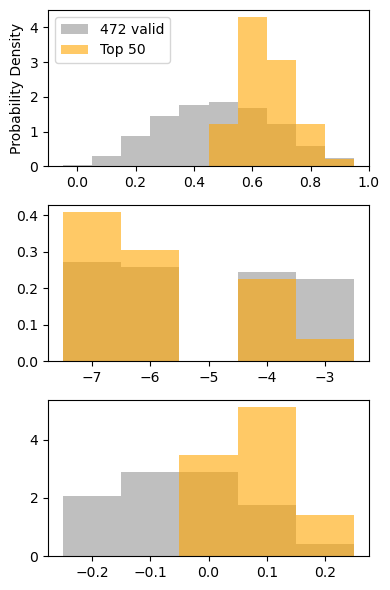

In [117]:
fig, axs = plt.subplots(3, 1, tight_layout=True, figsize=(4, 6))



axs[0].hist(change_po4_prior, bins = bins_po4, density=True, #call histogram method on axs object axs[0]
            alpha=0.5, color='grey', label='472 valid', align='mid')  

axs[0].hist(change_po4_post, bins = bins_po4, density=True,
            alpha=0.6, color='orange', label='Top 50', align='mid')

axs[1].hist(change_temp_prior, bins = temp_bins, density=True, #call histogram method on axs object axs[0]
            alpha=0.5, color='grey', label='472 valid', align='mid')  

axs[1].hist(change_temp_post, bins = temp_bins, density=True,
            alpha=0.6, color='orange', label='Top 50', align='mid')

axs[2].hist(change_po2_prior, bins = bins_pO2, density=True, #call histogram method on axs object axs[0]
            alpha=0.5, color='grey', label='472 valid', align='mid')  

axs[2].hist(change_po2_post, bins = bins_pO2, density=True,
            alpha=0.6, color='orange', label='Top 50', align='mid')

# for ax, change_prior, change_post, label in zip(
#     axs,
#     [trans_df['pCO2_bg'], trans_df['pCO2_ev']],
#     [trans_df['pCO2_bg'].iloc[:50], trans_df['pCO2_ev'].iloc[:50]],
#     ['PO4', 'pO2']
# ):
#     # 500 selected
#     ax.hist(change_prior, bins=10, density=True,
#             alpha=0.5, color='grey', label='472 valid')

#     # 50 narrowed down
#     ax.hist(change_post, bins=10, density=True,
#             alpha=0.6, color='orange', label='Top 50')

#     ax.axvline(0, color='black', linestyle='--', alpha=0.5)
#     ax.set_xlabel(f'Δ{label}')
#     ax.set_title(f'{label} Change Distribution')

axs[0].set_ylabel('Probability Density')
axs[0].legend()
# # plt.suptitle('472 Valid vs Top 50 Distributions', y=1.02)
plt.show()

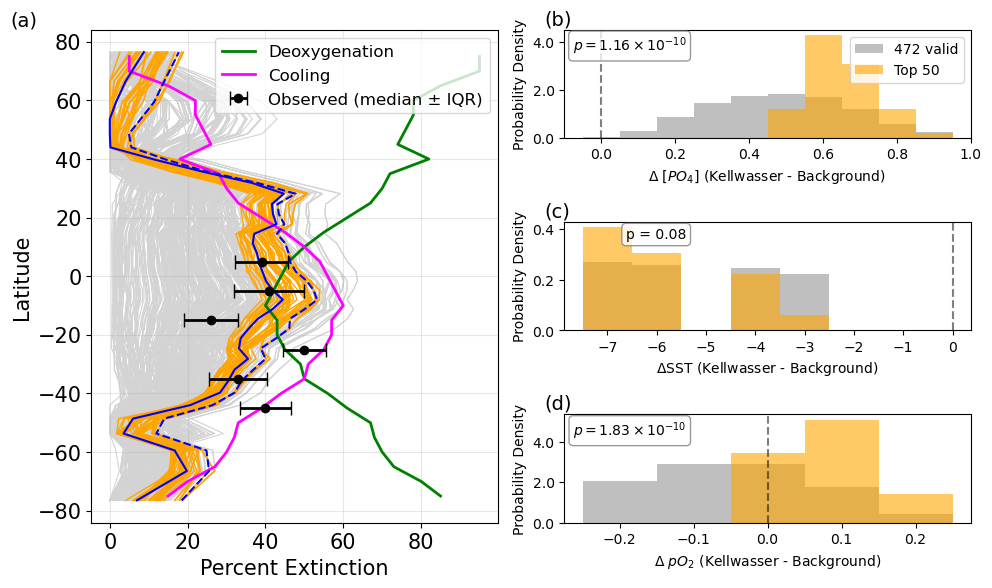

In [138]:
changes_prior = {
    'PO4': change_PO4_prior,
    'temp': change_temp_prior,
    'pO2': change_pO2_prior
}

changes_post = {
    'PO4': change_PO4_post,
    'temp': change_temp_post,
    'pO2': change_pO2_post
}

fig3 = [440]  
si = [379] 

fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(3, 2)
ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, 1])


for col in sims_df.columns[1:]:
    if col in fig3:
        ax1.plot(sims_df[col], sims_df['lat'],
                 color='blue', linewidth=1.5, zorder=3)
    if col in si:
        ax1.plot(sims_df[col], sims_df['lat'],
                 color='blue', linewidth=1.5, linestyle ="dashed", zorder=3)
        
    elif col in best_cols:
        ax1.plot(sims_df[col], sims_df['lat'],
                 color='orange', linewidth=1, zorder=2)
    else:
        ax1.plot(sims_df[col], sims_df['lat'],
                 color='lightgrey', linewidth=0.8, zorder=1)

        
ax1.plot(models['deoxygenation'], models['Latitude'], color='green', linewidth=2, label='Deoxygenation', zorder=2)
ax1.plot(models['cooling'], models['Latitude'], color='magenta', linewidth=2, label='Cooling', zorder=2)
ax1.errorbar(merged_df['median'], merged_df['latbin'],
             xerr=merged_df['iqr']/2,
             fmt='o', color='black', ecolor='black',
             capsize=5, markersize=6, linewidth=2,
             label='Observed (median ± IQR)', zorder=4)
ax1.set_ylabel("Latitude", fontsize=15)
ax1.set_xlabel("Percent Extinction", fontsize=15)
ax1.tick_params(axis='both', labelsize=15)
ax1.text(
    -0.2, 1.0, '(a)',
    transform=ax1.transAxes,
    fontsize=14,
    va='bottom',
    ha='left'
)
ax1.legend(fontsize=12, loc='upper right')
ax1.grid(True, alpha=0.3)

ax2.hist(change_po4_prior, bins = bins_po4, density=True, #call histogram method on axs object axs[0]
            alpha=0.5, color='grey', label='472 valid', align='mid')  

ax2.hist(change_po4_post, bins = bins_po4, density=True,
            alpha=0.6, color='orange', label='Top 50', align='mid')

ax3.hist(change_temp_prior, bins = temp_bins, density=True, #call histogram method on axs object axs[0]
            alpha=0.5, color='grey', label='472 valid', align='mid')  

ax3.hist(change_temp_post, bins = temp_bins, density=True,
            alpha=0.6, color='orange', label='Top 50', align='mid')

ax4.hist(change_po2_prior, bins = bins_pO2, density=True, #call histogram method on axs object axs[0]
            alpha=0.5, color='grey', label='472 valid', align='mid')  

ax4.hist(change_po2_post, bins = bins_pO2, density=True,
            alpha=0.6, color='orange', label='Top 50', align='mid')


for ax, label, panel in zip(
    [ax2, ax3, ax4],
    ['PO4', 'temp', 'pO2'],
    ['(b)', '(c)', '(d)']
):
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_ylabel('Probability Density')
    ax.yaxis.set_major_formatter('{x:,.1f}')  # set y tick digits to 1
    
    ks_stat, ks_p = stats.ks_2samp(changes_prior[label], changes_post[label])
    if ks_p >= 0.01:
        p_text = f"p = {ks_p:.2f}"
    else:
        exponent = int(np.floor(np.log10(ks_p)))
        mantissa = ks_p / 10**exponent
        p_text = rf"$p = {mantissa:.2f}\times10^{{{exponent}}}$"

    
    # p_text = f'p = {ks_p:.2f}' if ks_p >= 0.01 else f'p = {ks_p:.2e}'
    ax.text(0.3, 0.95, p_text,
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey', alpha=0.8))
    ax.text(-0.05, 1.05, panel , transform=ax.transAxes, fontsize=14)

ax2.set_xlabel(r'$\Delta$ $[PO_{4}]$ (Kellwasser - Background) ')
ax3.set_xlabel(r'$\Delta$SST (Kellwasser - Background)')
ax4.set_xlabel(r'$\Delta$ $\it{p}O_{2}$ (Kellwasser - Background)')

ax2.legend()

plt.tight_layout()
# plt.savefig("../figures/posterior_distributions.png")
plt.show()